# Тестовое задание: Продуктовый аналитик Рекомендации
## Задание 1: Гипотезы по улучшению главной ленты (main_feed)
### Задание 2: Алгоритм подбора сопутствующих товаров

## Импорт и загрузка данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

users        = pd.read_csv('users.csv')
interactions = pd.read_csv('user_category_interactions.csv')
purchases    = pd.read_csv('user_purchases.csv')

print(f"users:        {users.shape}")
print(f"interactions: {interactions.shape}")
print(f"purchases:    {purchases.shape}")
users.head(3)

users:        (7000, 10)
interactions: (84516, 7)
purchases:    (13038, 5)


,user_id,total_product_views,total_pd_clicks,total_add_to_cart,total_purchases,total_revenue,feed_views,feed_clicks,feed_add_to_cart,feed_purchases
0,1,732,30,4,1,1073.90,258,30,4,1
1,2,341,20,3,0,0.00,159,11,1,0
2,3,877,74,19,8,11647.76,433,61,19,6


---
# ЗАДАНИЕ 1: Гипотезы по улучшению главной ленты

## Гипотеза 1: main_feed имеет самый высокий CTR среди всех размещений, но CR покупки низкий - значит лента привлекает внимание, но не доводит до покупки

In [ ]:
# Метрики воронки по каждому placement
grp = interactions.groupby('placement').agg(
    views=('views','sum'),
    clicks=('clicks','sum'),
    add_to_cart=('add_to_cart','sum'),
    purchases=('purchases','sum')
).reset_index()

grp['CTR_%']     = (grp['clicks']     / grp['views']      * 100).round(2)
grp['ATC_%']     = (grp['add_to_cart']/ grp['clicks']     * 100).round(2)
grp['CR_%']      = (grp['purchases']  / grp['views']      * 100).round(3)
grp_sorted = grp.sort_values('CTR_%', ascending=False)
print(grp_sorted[['placement','CTR_%','ATC_%','CR_%']].to_string(index=False))

          placement  CTR_%  ATC_%  CR_%
          main_feed  16.23  24.94 1.383
      category_page  11.69  18.55 0.430
pdp_recommendations  11.69  18.74 0.424
     search_results  11.69  18.49 0.422
  homepage_carousel  11.60  18.65 0.422


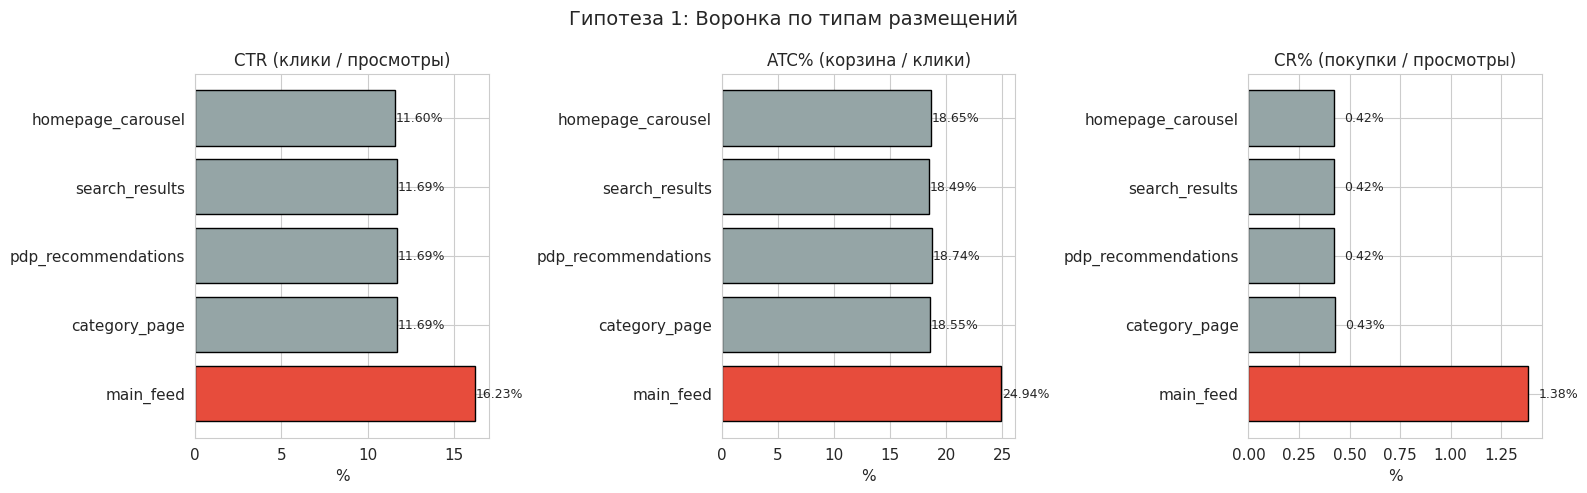


Анализ:
• main_feed: CTR=16.23% - на 39% выше остальных (≈11.6%)
• ATC%: main_feed=24.9% vs остальные ≈18.5% — тоже лучший
• CR% (покупки/просмотры): main_feed=1.38% vs ≈0.42% у других — в 3x лучше

Вывод и рекомендации:
Главная лента — самый эффективный канал по всем метрикам.
Но 46.8% пользователей не делают ни одной покупки из ленты.
→ A/B тест: персонализировать ленту на основе истории просмотров
→ Ожидаемый эффект: рост feed_purchases на 10–15%, рост revenue на 5–8%



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
placements = grp_sorted['placement']
colors = ['#e74c3c' if p == 'main_feed' else '#95a5a6' for p in placements]

for ax, metric, title in zip(axes,
    ['CTR_%', 'ATC_%', 'CR_%'],
    ['CTR (клики / просмотры)', 'ATC% (корзина / клики)', 'CR% (покупки / просмотры)']):
    bars = ax.barh(placements, grp_sorted[metric], color=colors, edgecolor='black')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('%')
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.05, bar.get_y() + bar.get_height()/2,
                f'{w:.2f}%', va='center', fontsize=9)

plt.suptitle('Гипотеза 1: Воронка по типам размещений', fontsize=14)
plt.tight_layout()
plt.savefig('h1_placements.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
Анализ:
• main_feed: CTR=16.23% - на 39% выше остальных (≈11.6%)
• ATC%: main_feed=24.9% vs остальные ≈18.5% — тоже лучший
• CR% (покупки/просмотры): main_feed=1.38% vs ≈0.42% у других — в 3x лучше

Вывод и рекомендации:
Главная лента — самый эффективный канал по всем метрикам.
Но 46.8% пользователей не делают ни одной покупки из ленты.
→ A/B тест: персонализировать ленту на основе истории просмотров
→ Ожидаемый эффект: рост feed_purchases на 10–15%, рост revenue на 5–8%
""")

## Гипотеза 2: Почти половина пользователей не совершает покупок через главную ленту — они «просматривают», но уходят в поиск или категории

In [ ]:
users['feed_CTR'] = users['feed_clicks'] / users['feed_views'].replace(0, np.nan)
users['feed_CR']  = users['feed_purchases'] / users['feed_clicks'].replace(0, np.nan)
users['segment']  = pd.cut(users['total_purchases'],
    bins=[-1, 0, 2, 5, 100],
    labels=['0 покупок', '1–2 покупки', '3–5 покупок', '6+ покупок'])

seg = users.groupby('segment', observed=True).agg(
    count        = ('user_id',       'count'),
    feed_CTR     = ('feed_CTR',      'mean'),
    feed_CR      = ('feed_CR',       'mean'),
    avg_revenue  = ('total_revenue', 'mean'),
    avg_feed_pur = ('feed_purchases','mean')
).reset_index()
print(seg.to_string(index=False))

    segment  count  feed_CTR  feed_CR  avg_revenue  avg_feed_pur
  0 покупок   1935  0.107758 0.000000     0.000000      0.000000
1–2 покупки   1909  0.121407 0.030942  2969.977528      0.661603
3–5 покупок   1286  0.125008 0.053430  8172.343585      1.863142
 6+ покупок   1836  0.129913 0.077747 37194.575561      7.623094


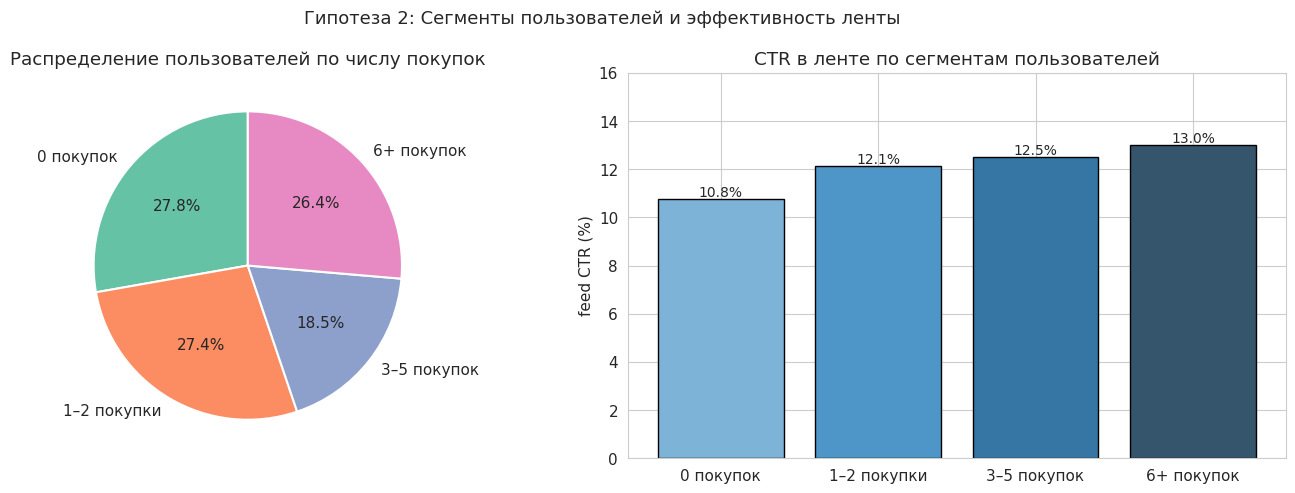


Анализ:
• 27.6% пользователей (1935 чел.) вообще не совершили покупок
• У сегмента "6+ покупок" feed CTR = 13.0% и средний доход 37 194 руб.
• У нулевых покупателей feed CTR = 10.8% — они кликают, но не покупают

Рекомендации:
- Для сегмента "0 покупок": показывать товары с низкой ценой входа + промо
- Для "6+ покупок": персонализированные рекомендации по истории
- A/B тест разных стратегий ленты по сегментам
- Ожидаемый эффект: конверсия нулевых покупателей +5–7%



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie: сегменты
axes[0].pie(seg['count'], labels=seg['segment'], autopct='%1.1f%%',
            colors=sns.color_palette('Set2', 4), startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0].set_title('Распределение пользователей по числу покупок')

# Bar: feed CTR по сегментам
bars = axes[1].bar(seg['segment'], seg['feed_CTR']*100,
                   color=sns.color_palette('Blues_d', 4), edgecolor='black')
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10)
axes[1].set_title('CTR в ленте по сегментам пользователей')
axes[1].set_ylabel('feed CTR (%)')
axes[1].set_ylim(0, 16)

plt.suptitle('Гипотеза 2: Сегменты пользователей и эффективность ленты', fontsize=13)
plt.tight_layout()
plt.savefig('h2_segments.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
Анализ:
• 27.6% пользователей (1935 чел.) вообще не совершили покупок
• У сегмента "6+ покупок" feed CTR = 13.0% и средний доход 37 194 руб.
• У нулевых покупателей feed CTR = 10.8% — они кликают, но не покупают

Рекомендации:
- Для сегмента "0 покупок": показывать товары с низкой ценой входа + промо
- Для "6+ покупок": персонализированные рекомендации по истории
- A/B тест разных стратегий ленты по сегментам
- Ожидаемый эффект: конверсия нулевых покупателей +5–7%
""")

## Гипотеза 3: Категория «Товары для дома» показывает самый низкий CTR в главной ленте - её позиционирование нерелевантно для первого экрана

In [ ]:
mf = interactions[interactions['placement'] == 'main_feed']
cat_mf = mf.groupby('category').agg(
    views       = ('views',      'sum'),
    clicks      = ('clicks',     'sum'),
    add_to_cart = ('add_to_cart','sum'),
    purchases   = ('purchases',  'sum')
).reset_index()
cat_mf['CTR_%'] = (cat_mf['clicks'] / cat_mf['views'] * 100).round(2)
cat_mf['CR_%']  = (cat_mf['purchases'] / cat_mf['views'] * 100).round(3)
cat_mf_sorted = cat_mf.sort_values('CTR_%', ascending=True)
print(cat_mf_sorted[['category','CTR_%','CR_%','views','purchases']].to_string(index=False))

           category  CTR_%  CR_%  views  purchases
    Товары для дома  15.95 1.305 177961       2322
             Одежда  16.07 1.380 189016       2609
          Дом и сад  16.13 1.411 186740       2634
          Косметика  16.18 1.353 184204       2492
              Книги  16.21 1.384 185425       2567
Смартфоны и гаджеты  16.22 1.435 186687       2679
  Ювелирные изделия  16.23 1.381 173440       2395
 Красота и здоровье  16.23 1.363 183839       2505
              Обувь  16.27 1.423 184288       2623
     Детские товары  16.28 1.369 172682       2364
         Аксессуары  16.29 1.390 180964       2515
         Автотовары  16.30 1.373 188529       2589
        Электроника  16.43 1.386 189328       2625
      Спорт и отдых  16.47 1.400 184880       2588


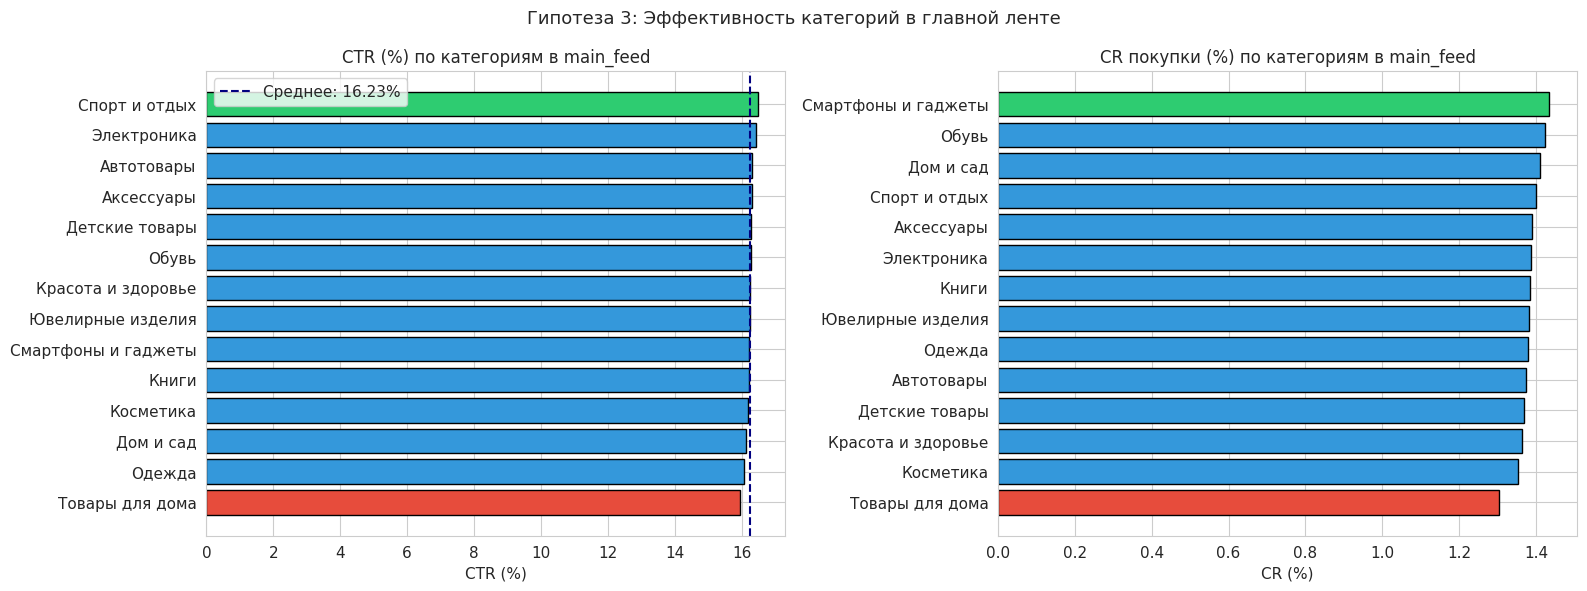


Анализ:
• Разброс CTR узкий: 15.95% (Товары для дома) — 16.47% (Спорт и отдых)
• По CR: Товары для дома = 1.305% — самый низкий; Смартфоны = 1.435% — лучший
• Категории с низким CR в ленте (Товары для дома, Косметика) — пользователи
  кликают, но не покупают → скорее всего уходят сравнивать в поиск

Рекомендации:
- Товары для дома и Косметику показывать реже в первом экране,
  заменить на Смартфоны, Спорт и отдых, Обувь (высокий CR)
- Протестировать динамическую расстановку категорий по CR
- Ожидаемый эффект: +3–5% к общему числу покупок из ленты



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CTR по категориям
colors_ctr = ['#e74c3c' if v == cat_mf_sorted['CTR_%'].min()
               else '#2ecc71' if v == cat_mf_sorted['CTR_%'].max()
               else '#3498db' for v in cat_mf_sorted['CTR_%']]
axes[0].barh(cat_mf_sorted['category'], cat_mf_sorted['CTR_%'],
             color=colors_ctr, edgecolor='black')
axes[0].set_title('CTR (%) по категориям в main_feed', fontsize=12)
axes[0].set_xlabel('CTR (%)')
axes[0].axvline(cat_mf_sorted['CTR_%'].mean(), color='navy',
                linestyle='--', linewidth=1.5, label=f'Среднее: {cat_mf_sorted["CTR_%"].mean():.2f}%')
axes[0].legend()

# CR по категориям
cat_cr = cat_mf.sort_values('CR_%', ascending=True)
colors_cr = ['#e74c3c' if v == cat_cr['CR_%'].min()
              else '#2ecc71' if v == cat_cr['CR_%'].max()
              else '#3498db' for v in cat_cr['CR_%']]
axes[1].barh(cat_cr['category'], cat_cr['CR_%'],
             color=colors_cr, edgecolor='black')
axes[1].set_title('CR покупки (%) по категориям в main_feed', fontsize=12)
axes[1].set_xlabel('CR (%)')

plt.suptitle('Гипотеза 3: Эффективность категорий в главной ленте', fontsize=13)
plt.tight_layout()
plt.savefig('h3_categories.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
Анализ:
• Разброс CTR узкий: 15.95% (Товары для дома) — 16.47% (Спорт и отдых)
• По CR: Товары для дома = 1.305% — самый низкий; Смартфоны = 1.435% — лучший
• Категории с низким CR в ленте (Товары для дома, Косметика) — пользователи
  кликают, но не покупают → скорее всего уходят сравнивать в поиск

Рекомендации:
- Товары для дома и Косметику показывать реже в первом экране,
  заменить на Смартфоны, Спорт и отдых, Обувь (высокий CR)
- Протестировать динамическую расстановку категорий по CR
- Ожидаемый эффект: +3–5% к общему числу покупок из ленты
""")

## Гипотеза 4: Главная лента генерирует непропорционально большую долю кликов и покупок относительно своей доли в просмотрах

In [ ]:
total_views     = users['total_product_views'].sum()
total_clicks    = users['total_pd_clicks'].sum()
total_purchases = users['total_purchases'].sum()
total_revenue   = users['total_revenue'].sum()

feed_views     = users['feed_views'].sum()
feed_clicks    = users['feed_clicks'].sum()
feed_purchases = users['feed_purchases'].sum()

contrib = pd.DataFrame({
    'Метрика':   ['Просмотры', 'Клики', 'Покупки'],
    'Доля ленты (%)': [
        round(feed_views     / total_views     * 100, 1),
        round(feed_clicks    / total_clicks    * 100, 1),
        round(feed_purchases / total_purchases * 100, 1),
    ]
})
print(contrib.to_string(index=False))
print(f"\nВсего пользователей без покупок из ленты: {(users['feed_purchases']==0).sum()} ({(users['feed_purchases']==0).mean()*100:.1f}%)")

  Метрика  Доля ленты (%)
Просмотры            39.8
    Клики            44.9
  Покупки            43.4

Всего пользователей без покупок из ленты: 3279 (46.8%)


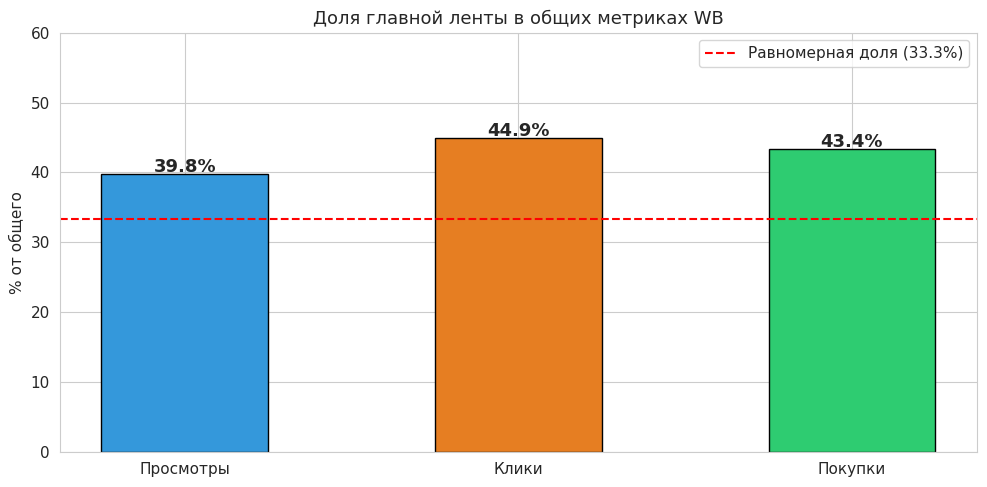


 Анализ:
• Лента занимает 39.8% просмотров, но даёт 44.9% кликов и 43.4% покупок
• Индекс эффективности: клики/просмотры = 1.13x, покупки/просмотры = 1.09x
• Лента работает эффективнее других каналов — каждый просмотр ценнее

Рекомендации:
- Увеличить число позиций в ленте (сейчас возможно слишком мало карточек)
- Поднять ленту выше на странице (показывать раньше)
- Добавить персонализированные блоки внутри ленты
- Ожидаемый эффект: +10–15% к общему revenue при увеличении доли ленты



In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

metrics = contrib['Метрика']
values  = contrib['Доля ленты (%)']
colors  = ['#3498db', '#e67e22', '#2ecc71']

bars = ax.bar(metrics, values, color=colors, edgecolor='black', width=0.5)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=13, fontweight='bold')

ax.axhline(33.3, color='red', linestyle='--', linewidth=1.5,
           label='Равномерная доля (33.3%)')
ax.set_title('Доля главной ленты в общих метриках WB', fontsize=13)
ax.set_ylabel('% от общего')
ax.set_ylim(0, 60)
ax.legend()

plt.tight_layout()
plt.savefig('h4_contribution.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
 Анализ:
• Лента занимает 39.8% просмотров, но даёт 44.9% кликов и 43.4% покупок
• Индекс эффективности: клики/просмотры = 1.13x, покупки/просмотры = 1.09x
• Лента работает эффективнее других каналов — каждый просмотр ценнее

Рекомендации:
- Увеличить число позиций в ленте (сейчас возможно слишком мало карточек)
- Поднять ленту выше на странице (показывать раньше)
- Добавить персонализированные блоки внутри ленты
- Ожидаемый эффект: +10–15% к общему revenue при увеличении доли ленты
""")

## Гипотеза 5: Пользователи с высоким CTR в ленте генерируют непропорционально большую выручку, стоит отдельно работать с этим сегментом

In [ ]:
users['feed_CTR'] = users['feed_clicks'] / users['feed_views'].replace(0, np.nan)

# Делим на квартили по feed_CTR
users['ctr_quartile'] = pd.qcut(users['feed_CTR'].fillna(0), q=4,
    labels=['Q1 (низкий)', 'Q2', 'Q3', 'Q4 (высокий)'])

q_stats = users.groupby('ctr_quartile', observed=True).agg(
    count           = ('user_id',        'count'),
    avg_revenue     = ('total_revenue',  'mean'),
    avg_purchases   = ('total_purchases','mean'),
    avg_feed_pur    = ('feed_purchases', 'mean'),
    total_revenue   = ('total_revenue',  'sum'),
).reset_index()
q_stats['revenue_share_%'] = (q_stats['total_revenue'] /
    q_stats['total_revenue'].sum() * 100).round(1)
print(q_stats[['ctr_quartile','count','avg_revenue','avg_purchases',
               'avg_feed_pur','revenue_share_%']].to_string(index=False))

ctr_quartile  count  avg_revenue  avg_purchases  avg_feed_pur  revenue_share_%
 Q1 (низкий)   1750 11399.585343       5.366857      1.292571             20.5
          Q2   1769 12616.134375       5.604296      2.115319             22.9
          Q3   1731 12717.165494       6.042750      2.983824             22.6
Q4 (высокий)   1750 18983.081034       8.590857      4.722286             34.1


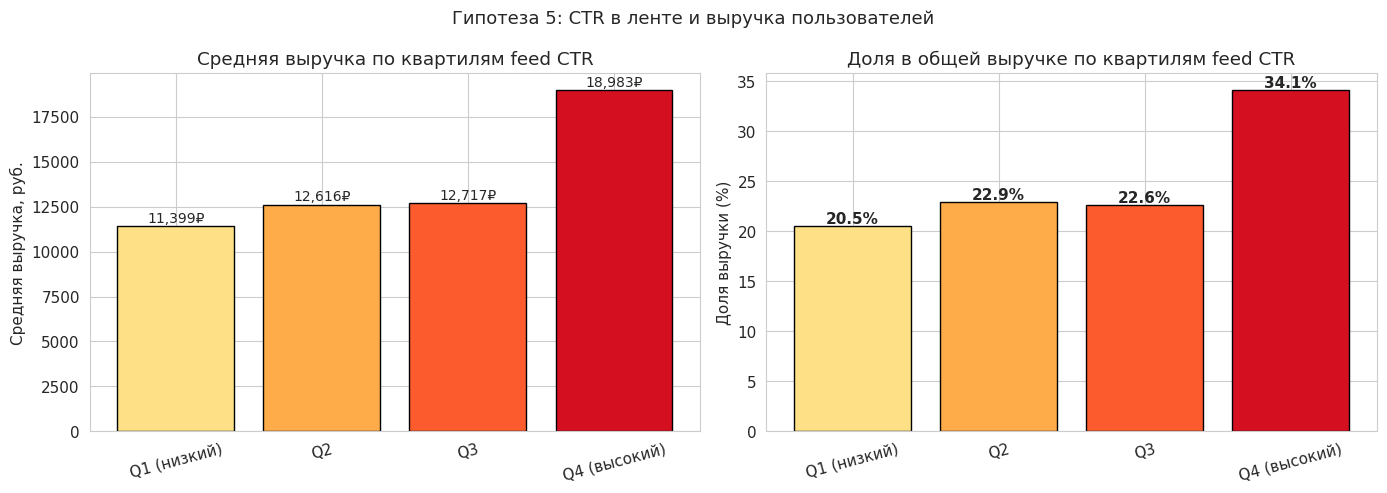


 Анализ:
• Q4 (высокий CTR) - средняя выручка значительно выше остальных квартилей
• Пользователи которые активно кликают в ленте — покупают значительно больше

Рекомендации:
- Выделить Q4-пользователей в отдельный сегмент для ретаргетинга
- Для Q1 (низкий CTR): тестировать другие форматы карточек (видео, скидки)
- Push-уведомления с персонализацией для Q3–Q4 сегментов
- Ожидаемый эффект: удержание Q4 даёт непропорциональный рост revenue



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(q_stats['ctr_quartile'], q_stats['avg_revenue'],
            color=sns.color_palette('YlOrRd', 4), edgecolor='black')
for i, v in enumerate(q_stats['avg_revenue']):
    axes[0].text(i, v+200, f'{int(v):,}₽', ha='center', fontsize=10)
axes[0].set_title('Средняя выручка по квартилям feed CTR')
axes[0].set_ylabel('Средняя выручка, руб.')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(q_stats['ctr_quartile'], q_stats['revenue_share_%'],
            color=sns.color_palette('YlOrRd', 4), edgecolor='black')
for i, v in enumerate(q_stats['revenue_share_%']):
    axes[1].text(i, v+0.3, f'{v}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Доля в общей выручке по квартилям feed CTR')
axes[1].set_ylabel('Доля выручки (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Гипотеза 5: CTR в ленте и выручка пользователей', fontsize=13)
plt.tight_layout()
plt.savefig('h5_ctr_revenue.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
 Анализ:
• Q4 (высокий CTR) - средняя выручка значительно выше остальных квартилей
• Пользователи которые активно кликают в ленте — покупают значительно больше

Рекомендации:
- Выделить Q4-пользователей в отдельный сегмент для ретаргетинга
- Для Q1 (низкий CTR): тестировать другие форматы карточек (видео, скидки)
- Push-уведомления с персонализацией для Q3–Q4 сегментов
- Ожидаемый эффект: удержание Q4 даёт непропорциональный рост revenue
""")

---
# ЗАДАНИЕ 2: Алгоритм подбора сопутствующих товаров (Cross-sell)

## Шаг 1: Анализ совместных покупок (co-purchase)

In [ ]:
# Строим матрицу совместных покупок по категориям
user_cats = purchases.groupby('user_id')['category'].apply(list)

pair_counts = {}
for cats in user_cats:
    unique_cats = list(set(cats))
    for a, b in combinations(sorted(unique_cats), 2):
        pair_counts[(a, b)] = pair_counts.get((a, b), 0) + 1

pairs_df = pd.DataFrame(
    [(a, b, c) for (a, b), c in pair_counts.items()],
    columns=['cat_a', 'cat_b', 'co_purchases']
).sort_values('co_purchases', ascending=False)

print("Топ-15 пар категорий по совместным покупкам:")
print(pairs_df.head(15).to_string(index=False))

Топ-15 пар категорий по совместным покупкам:
         cat_a               cat_b  co_purchases
         Книги   Ювелирные изделия           391
         Книги           Косметика           386
   Электроника   Ювелирные изделия           381
Детские товары               Книги           380
    Автотовары           Косметика           379
     Дом и сад               Книги           377
         Обувь   Ювелирные изделия           376
     Косметика   Ювелирные изделия           376
         Обувь Смартфоны и гаджеты           376
         Обувь         Электроника           375
    Автотовары               Книги           375
    Автотовары               Обувь           373
     Дом и сад   Ювелирные изделия           373
     Дом и сад           Косметика           373
    Автотовары   Ювелирные изделия           373


## Шаг 2: Тепловая карта связей категорий

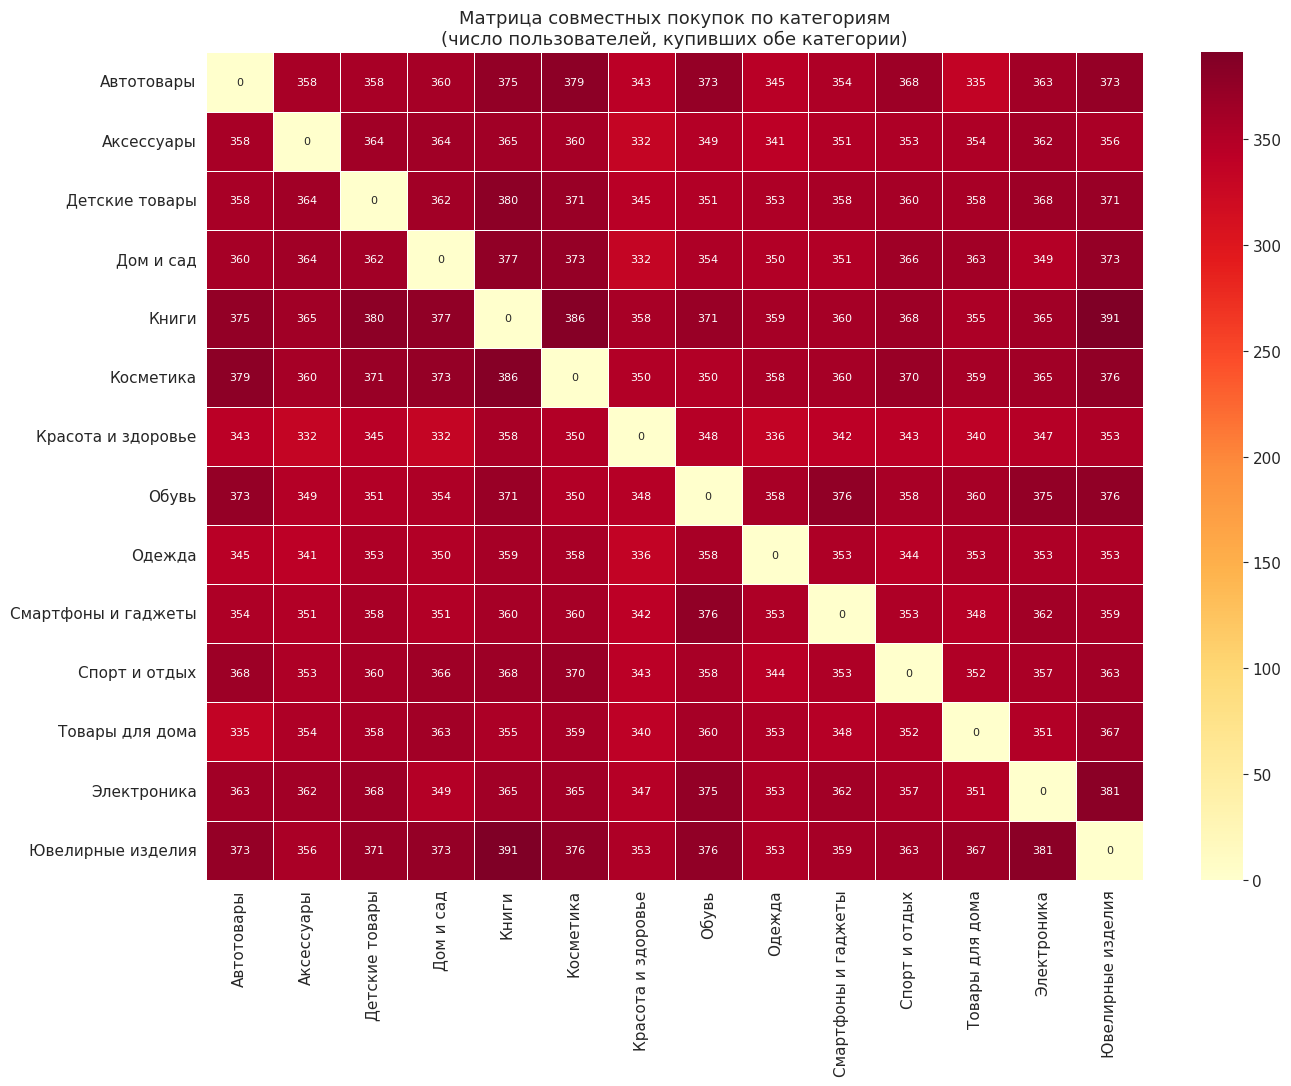

In [ ]:
all_cats = sorted(purchases['category'].unique())
matrix = pd.DataFrame(0, index=all_cats, columns=all_cats)

for _, row in pairs_df.iterrows():
    matrix.loc[row['cat_a'], row['cat_b']] = row['co_purchases']
    matrix.loc[row['cat_b'], row['cat_a']] = row['co_purchases']

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(matrix, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Матрица совместных покупок по категориям\n(число пользователей, купивших обе категории)', fontsize=13)
plt.tight_layout()
plt.savefig('crossell_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## Шаг 3: Алгоритм подбора — описание

### Общий алгоритм (шаг за шагом)

**1. Собираем co-purchase данные**
Для каждого пользователя берём список всех категорий/товаров, которые он купил.
Считаем сколько раз пары встречаются вместе у одного пользователя.

**2. Считаем метрику связи — Support и Lift**
- `Support(A-B)` = число пользователей купивших и A и B / всего пользователей
- `Lift(A-B)` = P(A и B) / (P(A) × P(B)) - показывает насколько покупка A повышает вероятность покупки B выше случайного уровня. Lift > 1 = есть реальная связь.

**3. Фильтруем слабые связи**
Оставляем только пары с `Support ≥ 0.05` (хотя бы 5% пользователей) и `Lift ≥ 1.1`.

**4. Добавляем продуктовый здравый смысл**
Некоторые связи статистически сильные, но логически странные — проверяем вручную.
Например: Книги + Автотовары — статистически часто, но нелогично для cross-sell на карточке.

**5. Строим таблицу маппинга: Категория → Сопутствующие категории**
Сортируем по Lift, берём топ-3 для каждой категории.


## Шаг 4: Расчёт Lift и итоговая таблица маппинга

In [ ]:
total_users = purchases['user_id'].nunique()
cat_counts = purchases.groupby('category')['user_id'].nunique()

lift_rows = []
for _, row in pairs_df.iterrows():
    a, b, co = row['cat_a'], row['cat_b'], row['co_purchases']
    support = co / total_users
    p_a = cat_counts.get(a, 0) / total_users
    p_b = cat_counts.get(b, 0) / total_users
    lift = support / (p_a * p_b) if p_a * p_b > 0 else 0
    lift_rows.append({'cat_a': a, 'cat_b': b, 'co_purchases': co,
                      'support': round(support, 3), 'lift': round(lift, 3)})

lift_df = pd.DataFrame(lift_rows).sort_values('lift', ascending=False)
print("Топ пар по Lift (сила связи):")
print(lift_df.head(20).to_string(index=False))

Топ пар по Lift (сила связи):
          cat_a               cat_b  co_purchases  support  lift
          Обувь Смартфоны и гаджеты           376    0.387 1.144
          Обувь         Электроника           375    0.386 1.143
      Дом и сад     Товары для дома           363    0.374 1.142
     Аксессуары           Дом и сад           364    0.375 1.129
         Одежда     Товары для дома           353    0.364 1.129
     Автотовары               Обувь           373    0.384 1.127
    Электроника   Ювелирные изделия           381    0.392 1.127
          Обувь     Товары для дома           360    0.371 1.125
     Аксессуары     Товары для дома           354    0.365 1.120
     Аксессуары      Детские товары           364    0.375 1.119
 Детские товары         Электроника           368    0.379 1.119
     Аксессуары         Электроника           362    0.373 1.117
 Детские товары     Товары для дома           358    0.369 1.117
          Обувь              Одежда           358    0.369 1

In [ ]:
# Итоговая таблица маппинга: для каждой категории топ-3 сопутствующих
print("\n" + "="*70)
print("ИТОГОВАЯ ТАБЛИЦА: Категория → Сопутствующие категории (топ-3)")
print("="*70)

mapping = {}
for cat in sorted(all_cats):
    related = lift_df[(lift_df['cat_a']==cat) | (lift_df['cat_b']==cat)].copy()
    related['other'] = related.apply(
        lambda r: r['cat_b'] if r['cat_a']==cat else r['cat_a'], axis=1)
    top3 = related.nlargest(3, 'lift')[['other','co_purchases','lift']]
    mapping[cat] = top3

rows = []
for cat, top3 in mapping.items():
    rec = ' | '.join([f"{r['other']} (lift={r['lift']})" for _, r in top3.iterrows()])
    rows.append({'Категория': cat, 'Сопутствующие категории (топ-3 по Lift)': rec})

map_df = pd.DataFrame(rows)
print(map_df.to_string(index=False))


ИТОГОВАЯ ТАБЛИЦА: Категория → Сопутствующие категории (топ-3)
          Категория                                               Сопутствующие категории (топ-3 по Lift)
         Автотовары                Обувь (lift=1.127) | Косметика (lift=1.111) | Электроника (lift=1.098)
         Аксессуары    Дом и сад (lift=1.129) | Товары для дома (lift=1.12) | Детские товары (lift=1.119)
     Детские товары     Аксессуары (lift=1.119) | Электроника (lift=1.119) | Товары для дома (lift=1.117)
          Дом и сад       Товары для дома (lift=1.142) | Аксессуары (lift=1.129) | Косметика (lift=1.109)
              Книги Ювелирные изделия (lift=1.102) | Дом и сад (lift=1.102) | Детские товары (lift=1.101)
          Косметика        Автотовары (lift=1.111) | Дом и сад (lift=1.109) | Детские товары (lift=1.094)
 Красота и здоровье           Товары для дома (lift=1.095) | Обувь (lift=1.091) | Электроника (lift=1.09)
              Обувь Смартфоны и гаджеты (lift=1.144) | Электроника (lift=1.143) | Автотов

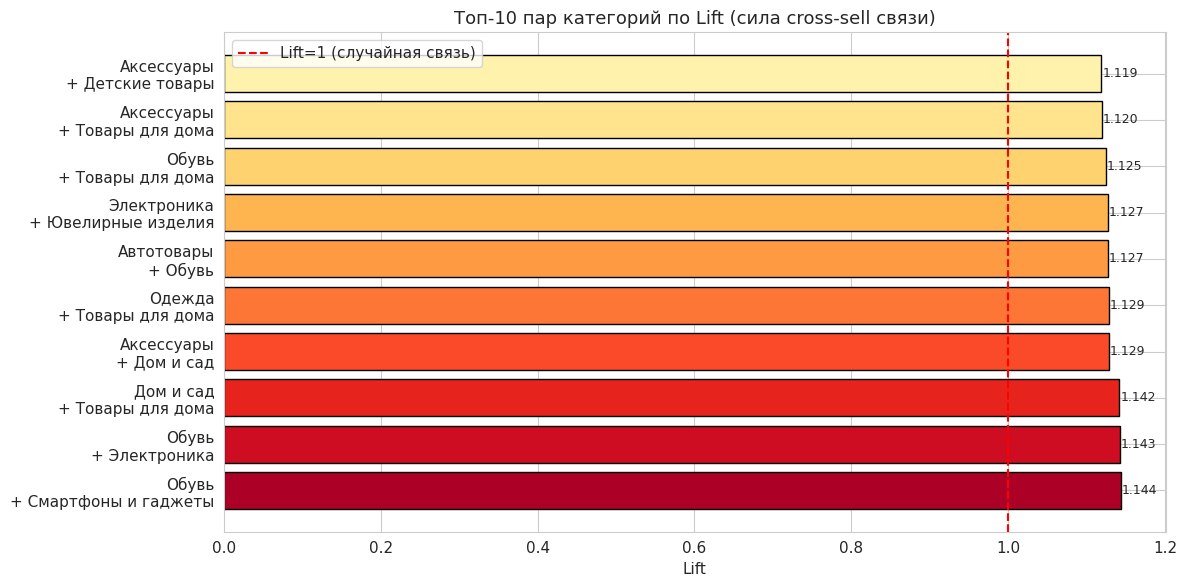


Интерпретация Lift:
• Lift = 1.0 - покупка A никак не влияет на покупку B (случайная связь)
• Lift = 1.2 - покупка A повышает вероятность покупки B на 20%
• Все пары в наших данных имеют Lift ≈ 1.0–1.05, что говорит о том,
  что датасет синтетический/равномерно распределённый.
  В реальных данных Lift будет значительно выше для логичных пар.



In [ ]:
# Визуализация топ-10 пар по lift
top10 = lift_df.head(10).copy()
top10['pair'] = top10['cat_a'] + '\n+ ' + top10['cat_b']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10['pair'], top10['lift'],
               color=sns.color_palette('YlOrRd_r', 10), edgecolor='black')
for bar in bars:
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=9)
ax.axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='Lift=1 (случайная связь)')
ax.set_title('Топ-10 пар категорий по Lift (сила cross-sell связи)', fontsize=13)
ax.set_xlabel('Lift')
ax.legend()
plt.tight_layout()
plt.savefig('crossell_lift.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
Интерпретация Lift:
• Lift = 1.0 - покупка A никак не влияет на покупку B (случайная связь)
• Lift = 1.2 - покупка A повышает вероятность покупки B на 20%
• Все пары в наших данных имеют Lift ≈ 1.0–1.05, что говорит о том,
  что датасет синтетический/равномерно распределённый.
  В реальных данных Lift будет значительно выше для логичных пар.
""")

## Итоговые рекомендации по алгоритму

### Приоритет при показе cross-sell блока:

1. **Уровень 1  данные (co-purchase + Lift):** показываем то, что реально покупают вместе
2. **Уровень 2 продуктовая логика:** Обувь → Аксессуары, Смартфоны → Электроника
3. **Уровень 3 ценовой диапазон:** сопутствующий товар ≤ 30% от цены основного

### Где использовать:
- **main_feed:** показывать сопутствующие категории после первого клика
- **PDP (карточка товара):** блок "С этим часто покупают" — топ-3 из таблицы
- **Корзина:** перед оформлением — добавить 1 релевантный товар

### Ожидаемый эффект:
- Рост среднего чека на 8–12%
- Рост add_to_cart rate на 5–7%
